In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
x = df[["area","bedrooms","bathrooms","stories","parking"]]
x.head()
x.isnull().sum()

,0
area,0
bedrooms,0
bathrooms,0
stories,0
parking,0


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [7]:
x_scaled[:5]

array([[ 1.04672629,  1.40341936,  1.42181174,  1.37821692,  1.51769249],
       [ 1.75700953,  1.40341936,  5.40580863,  2.53202371,  2.67940935],
       [ 2.21823241,  0.04727831,  1.42181174,  0.22441013,  1.51769249],
       [ 1.08362412,  1.40341936,  1.42181174,  0.22441013,  2.67940935],
       [ 1.04672629,  1.40341936, -0.57018671,  0.22441013,  1.51769249]])

In [9]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3,random_state=42)
model.fit(x_scaled)

KMeans(n_clusters=3, random_state=42)

In [10]:
labels = model.labels_
labels[:10]

array([1, 1, 2, 1, 2, 1, 1, 1, 2, 1], dtype=int32)

In [11]:
df["cluster"] = labels
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,cluster
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,2
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,2


In [12]:
df.groupby("cluster")[["area", "bedrooms", "bathrooms", "stories", "parking"]].mean()

,area,bedrooms,bathrooms,stories,parking
cluster,,,,,
0,4106.320423,2.700704,1.021127,1.623239,0.176056
1,5731.635714,3.600000,1.992857,2.492857,0.828571
2,6929.099174,2.851240,1.090909,1.438017,1.752066


In [18]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(x_scaled)
    inertia.append(model.inertia_)

In [14]:
model.fit(x_scaled)

KMeans(n_clusters=10, random_state=42)

In [15]:
inertia.append(model.inertia_)

In [16]:
print(inertia)

[846.394228897016]


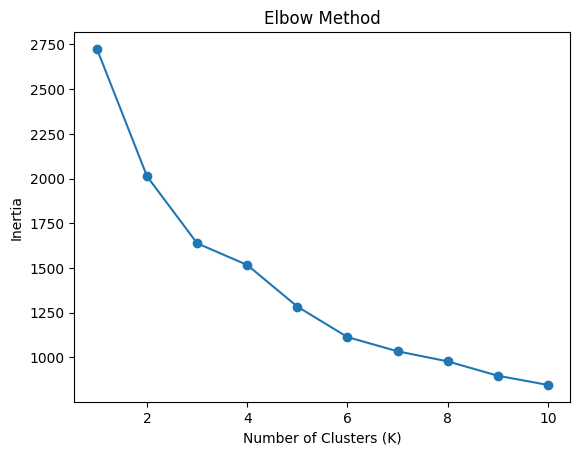

In [19]:
k_values = range(1, 11)

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [20]:
final_model = KMeans(n_clusters=4, random_state=42)
final_model.fit(x_scaled)
df["cluster"] = final_model.labels_

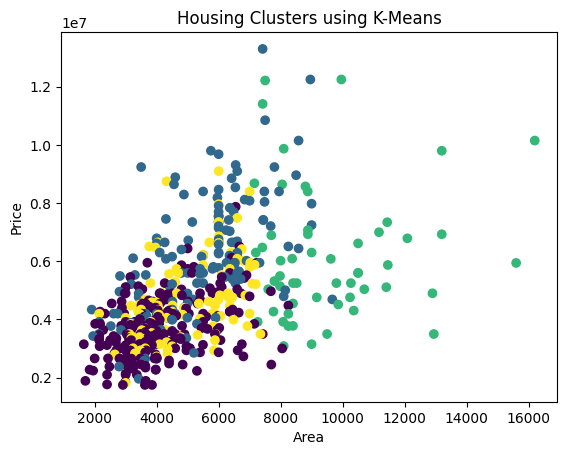

In [21]:
plt.scatter(df["area"], df["price"], c=df["cluster"])

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Housing Clusters using K-Means")
plt.show()